In [2]:
# rdflib is needed to read the knowledge graph provided in input

!pip install -U rdflib

In [3]:
# I am adding this because I had an error later, so upgrading this was suggested to avoid the error
# i don't know if this is actually needed or I can remove it

!pip install --upgrade pyparsing

In [4]:
from typing import TypedDict, List, Dict, Optional
from langgraph.graph import StateGraph, END

from rdflib import Graph
from langchain_community.chat_models import ChatOllama

None of PyTorch, TensorFlow >= 2.0, or Flax have been found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


In [5]:
# First step is using rdflib to load the graph as a whole rdf file in turtle format.
# Another way to go would be providing the sparql endpoint the graph is available at (doing this with apache jena fuseki)

g = Graph()
g.parse("./Desktop/aemet_turtle.ttl", format="ttl")

<Graph identifier=N83f652850468486fbc05ec31417b4603 (<class 'rdflib.graph.Graph'>)>

In [6]:
pip install -U langchain-ollama

Note: you may need to restart the kernel to use updated packages.


In [7]:
from langchain_ollama import ChatOllama

In [8]:
# We want to start a conversation with the model
# After this, when running the model, we expect it to provide a natural language message as an answer

from pprint import pprint
from langchain_core.messages import AIMessage, HumanMessage, SystemMessage

messages = [AIMessage(content=f"So you said you were researching ocean mammals?", name="Model")]
messages.extend([HumanMessage(content=f"Yes, that's right.", name="Lance")])
messages.extend([AIMessage(content=f"Great, what would you like to learn about.", name="Model")])
messages.extend([HumanMessage(content=f"I want to learn about the best place to see Orcas in the US.", name="Lance")])

for m in messages:
    m.pretty_print()

================================== Ai Message ==================================
Name: Model

So you said you were researching ocean mammals?
================================ Human Message =================================
Name: Lance

Yes, that's right.
================================== Ai Message ==================================
Name: Model

Great, what would you like to learn about.
================================ Human Message =================================
Name: Lance

I want to learn about the best place to see Orcas in the US.


Now we call the model.

I set the temperature = 1 to increase variability and creativity, since the task of the model would be to explore a graph and produce a SPARQL query from a natural language question. The model would need to explore different possibilities.

In [9]:
# After running ollama serve

llm = ChatOllama(
    model="gpt-oss:120b-cloud",
    temperature=1
)
result = llm.invoke(messages)

type(result)

langchain_core.messages.ai.AIMessage

If we show the results, the AIMessage has some content, containing the answer of the model to the last human message.

In [9]:
result.pretty_print()

================================== Ai Message ==================================

## The Ultimate Guide to Seeing Orcas (Killer Whales) in the United States  

Below is a compact “field‑guide” you can print or save on a phone/tablet before you head out. It covers the **best U.S. locations**, the **times of year** when sightings are most reliable, the **type of orca populations** you’ll encounter, and the **practical tips** (tour operators, gear, ethics, safety, and budgeting) that will help you get the most out of the experience.

---

### 1️⃣ Where to Go – Top U.S. Orca‑Watching Destinations  

| State | Primary Area(s) | Orca Population (type) | Typical Season | Why It’s Awesome |
|-------|----------------|------------------------|----------------|-----------------|
| **Washington** | **San Juan Islands (especially around Orcas Island, Friday Harbor, and the East Sound)** | **Southern Resident** (fish‑eating) | **April – October** (peak May‑July) | • Highest concentration of resident

In [10]:
result.response_metadata

{'model': 'gpt-oss:120b',
 'created_at': '2026-05-29T10:01:24.278840883Z',
 'done': True,
 'done_reason': 'stop',
 'total_duration': 39564661316,
 'load_duration': None,
 'prompt_eval_count': 123,
 'prompt_eval_duration': None,
 'eval_count': 3528,
 'eval_duration': None,
 'logprobs': None,
 'model_name': 'gpt-oss:120b',
 'model_provider': 'ollama'}

# Adding RAG into the pipeline

In [10]:
!pip install langchain-text-splitters

In [11]:
!pip install pypdf

Use Chroma as vector database: https://docs.trychroma.com/docs/overview/introduction.

In [12]:
pip install chromadb

Note: you may need to restart the kernel to use updated packages.


We use a local Ollama embedding model to convert text into vectors: ``nomic-embed-text``: https://ollama.com/library/nomic-embed-text.

In [14]:
from langchain_community.document_loaders import (PyPDFLoader, WebBaseLoader)
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import Chroma
from langchain_ollama import OllamaEmbeddings
from langchain.tools import tool
from langchain_community.document_loaders import RecursiveUrlLoader

PDF_PATHS = [
    "world_weather_attribution.pdf"
]

WEBSITE_URLS = [
"https://www.worldweatherattribution.org/climate-change-big-player-at-fifa-world-cup-2026/", 
    "https://www.worldweatherattribution.org/record-shattering-march-temperatures-in-western-north-america-virtually-impossible-without-climate-change/"  
]

# Load the documents
all_docs = []

# Load pdf
for pdf_path in PDF_PATHS:
    loader = PyPDFLoader(pdf_path)
    docs = loader.load()
    all_docs.extend(docs)

# Load websites
for url in WEBSITE_URLS:
    loader = WebBaseLoader(url)
    docs = loader.load()
    all_docs.extend(docs)
    
docs = loader.load()
print(f"Loaded {len(all_docs)} documents")

# Split documents (customizable)

splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=100
)

splits = splitter.split_documents(all_docs)

print(f"Created {len(splits)} chunks")

# generate embeddings and store them in a vector store with chroma

embeddings = OllamaEmbeddings(
    model="nomic-embed-text"
)

vectorstore = Chroma.from_documents(
    documents=splits,
    embedding=embeddings,
    persist_directory="./climate_rag_db"
)

# Optional: persist DB to disk
vectorstore.persist()

retriever = vectorstore.as_retriever(
    search_kwargs={"k": 4}
)



Loaded 8 documents
Created 113 chunks


/var/folders/m5/_gg_c8dx3_7cl1gy0wn_kn6r0000gn/T/ipykernel_19276/1800957650.py:59: LangChainDeprecationWarning: Since Chroma 0.4.x the manual persistence method is no longer supported as docs are automatically persisted.
  vectorstore.persist()


In [15]:
for i, doc in enumerate(docs):
    print(f"\n--- DOCUMENT {i} ---")
    print(doc.page_content[:10000])  # first 500 chars
    print(doc.metadata)


--- DOCUMENT 0 ---







Record-shattering March temperatures in Western North America virtually impossible without climate change – World Weather Attribution















































Skip to content








Home
About

FAQs
Methods
Information for journalists


Analyses

Drought
Extreme rainfall
Heatwave
Storms
Cold spells
Wildfire
Study tracker
By year


News
Peer reviewed research

Methodological papers
Event papers


 




Search for:










Search for:








Los Angeles is one of the areas under an extreme heat warning. Original public domain image from Wikimedia Commons
Home > Heatwave > Record-shattering March temperatures in Western North America virtually impossible without climate change




Record-shattering March temperatures in Western North America virtually impossible without climate change 

20 March, 2026
Heatwave
North America


An unusually early spring heatwave is developing across the southwestern United States (US), with temperatures t

In [16]:
for i, chunk in enumerate(splits):
    print(f"\n--- CHUNK {i} ---")
    print(chunk.page_content[:300])
    print(chunk.metadata)


--- CHUNK 0 ---
Tornado outbreak in the USA on 20 May 2013 
Dr. Susanne Haeseler; updated: 29. May 2013 
 
 
Introduction 
 
From mid-May 2013, there were an increased number of tornado outbreaks in the USA. Har-
dest hit was the region Newcastle – Moore – south Oklahoma City in the state of Oklahoma 
on the 20th (
{'producer': 'Acrobat Distiller 10.1.5 (Windows)', 'creator': 'Acrobat PDFMaker 10.1 für Word', 'creationdate': '2013-05-29T12:33:01+02:00', 'author': 'DWD, KU24B', 'comments': '', 'company': 'Deutscher Wetterdienst', 'keywords': '', 'moddate': '2013-05-29T12:33:09+02:00', 'sourcemodified': 'D:20130529080445', 'subject': '', 'title': '', 'source': 'world_weather_attribution.pdf', 'total_pages': 6, 'page': 0, 'page_label': '1'}

--- CHUNK 1 ---
On the morning of 20 May 2013, a low pressure system was centred over the central north of 
the USA (Fig. 2). An associated air mass frontier was located across the state of Oklahoma, 
only slowly moving eastward in the course of the 

In [17]:
print(len(splits))

113


In [19]:
embeddings

OllamaEmbeddings(model='nomic-embed-text', dimensions=None, validate_model_on_init=False, base_url=None, client_kwargs={}, async_client_kwargs={}, sync_client_kwargs={}, mirostat=None, mirostat_eta=None, mirostat_tau=None, num_ctx=None, num_gpu=None, keep_alive=None, num_thread=None, repeat_last_n=None, repeat_penalty=None, temperature=None, stop=None, tfs_z=None, top_k=None, top_p=None)

Now we start with the system message, where we prompt the system as an expert agent for answering climatolog questions.

It has access to two knowledge sources: a pdf document and web uris to exploit in a RAG system; a knowledge graph to explore with SPARQL.

In [18]:
from langgraph.graph import MessagesState
from langchain_core.messages import HumanMessage, SystemMessage

# System message
sys_msg = SystemMessage(content="""
You are an expert agent for answering climatology questions.

You have access to:

1. A semantic document retrieval tool
2. RDF knowledge graph tools.

You MUST perform first semantic search against the pdf document or web article with the 'semantic_search' tool.
You MUST use the semantic_search tool.
If you do not find an answer there, query the knowledge graph.

When running queries against the knowledge graph, your task is to write a SPARQL query to answer the given question. Follow a step-by-step process:
1. Use exploratory tools first to inspect the graph structure.
2. Only use run_sparql for testing candidate queries or executing the final query.
3. Start by constructing very simple fragments of the SPARQL query.
4. Execute each fragment to verify its correctness. Adjust as needed based on your observations.
5. Confirm all your assumptions about the structure of the knowledge graph before proceeding.
6. Gradually build the complete SPARQL query by adding one piece at a time.
7. Do NOT repeat the same action, as the results will be the same.
8. The question is guaranteed to have an answer in the knowledge graph, so continue until you find it.
9. Once you generate a query, you must run it against the knowledge graph by using the tool 'run_sparql'.
10. Once a valid result is returned to you, generate a final answer.

RDF SCHEMA

Allowed prefixes:

PREFIX geo: <http://www.w3.org/2003/01/geo/wgs84_pos#>
PREFIX sorelsc: <http://sweetontology.net/relaSci/>
PREFIX rdf: <http://www.w3.org/1999/02/22-rdf-syntax-ns#>
PREFIX owl: <http://www.w3.org/2002/07/owl#>
PREFIX skos: <http://www.w3.org/2004/02/skos/core#>
PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>
PREFIX time: <http://www.w3.org/2006/time#>
PREFIX foaf: <http://xmlns.com/foaf/0.1/>
PREFIX aemet: <http://aemet.linkeddata.es/ontology/>
PREFIX ssn: <http://purl.oclc.org/NET/ssnx/ssn#>
PREFIX sosa: <http://www.w3.org/ns/sosa/>

Allowed classes:

- ssn:Observation
- foaf:Agent
- aemet:Sensor
- aemet:AmbientProperty

Allowed predicates:

- time:day
- time:hour
- geo:long
- geo:lat
- rdfs:comment
- aemet:locatedInProvince
- ssn:observedBy
- sorelsc:hasImpact
- ssn:observedProperty

DOMAIN RULES

- Every weather event is an ssn:Observation.
- Every observation is linked to a sensor using ssn:observedBy.
- Every sensor is linked to a province using aemet:locatedInProvince.
- Every observation is linked to an ambient property using ssn:observedProperty.
- Province names always start with an uppercase letter and must preserve capitalization.

IMPORTANT CONSTRAINTS

- Use ONLY the classes and predicates listed above.
- NEVER invent predicates, classes, namespaces, or properties.
- Generate ONLY a SPARQL SELECT query.
- DO NOT include explanations.
- DO NOT include markdown.
- DO NOT include triple backticks.
- The output must be executable SPARQL only.

If you do not find any answer in the knowledge graph, perform semantic search against the pdf document or web article with the semantic_search tool.
An answer is guaranteed to be found either in the pdf document or in the knowledge graph.
""")

# Node
def assistant(state:MessagesState):
    return {"messages": [llm_with_tools.invoke([sys_msg] + state["messages"])]}

Next, we start defining all our functions:
- run_sparql
- list_predicates
- list_classes
- get_class_properties
- sample_instances
- describe_entity
- semantic_search

In [19]:
from langchain_core.messages import SystemMessage, HumanMessage
    
@tool
def run_sparql(query: str) -> dict:
    """Execute a SPARQL query and return results."""
    try:
        results = g.query(query)
        return [dict(row.asdict()) for row in results]
    except Exception as e:
        return {"error": str(e)}

@tool
def list_predicates(limit: int = 50) -> list:
    """Return predicates present in the knowledge graph."""
    query = f"""
    SELECT DISTINCT ?p
    WHERE {{
        ?s ?p ?o .
    }}
    LIMIT {limit}
    """
    
    try:
        results = g.query(query)
        return [str(row.p) for row in results]
    except Exception as e:
        return {"error": str(e)}

@tool
def list_classes(limit: int = 50) -> list:
    """Return RDF classes used in the knowledge graph."""
    
    query = f"""
    SELECT DISTINCT ?class
    WHERE {{
        ?s rdf:type ?class .
    }}
    LIMIT {limit}
    """

    try:
        results = g.query(query)
        return [str(row["class"]) for row in results]
    except Exception as e:
        return {"error": str(e)}

@tool
def get_class_properties(class_name: str) -> list:
    """
    Return predicates commonly associated with instances of a class.
    Example input: 'ssn:Observation'
    """
    if class_name.startswith("http"):
      class_name = "<" + class_name + ">"
        
    query = f"""
    SELECT DISTINCT ?p
    WHERE {{
        ?s rdf:type {class_name} .
        ?s ?p ?o .
    }}
    """

    try:
        results = g.query(query)
        return [str(row.p) for row in results]
    except Exception as e:
        return {"error": str(e)}

@tool
def sample_instances(class_name: str, limit: int = 10) -> list:
    """
    Return sample instances of a class.
    """
    if class_name.startswith("http"):
      class_name = "<" + class_name + ">"
      
    query = f"""
    SELECT DISTINCT ?s
    WHERE {{
        ?s rdf:type {class_name} .
    }}
    LIMIT {limit}
    """

    try:
        results = g.query(query)
        return [str(row.s) for row in results]
    except Exception as e:
        return {"error": str(e)}

@tool
def describe_entity(entity_uri: str) -> list:
    """
    Return triples associated with an entity URI.
    """

    query = f"""
    SELECT ?p ?o
    WHERE {{
        <{entity_uri}> ?p ?o .
    }}
    LIMIT 50
    """

    try:
        results = g.query(query)
        return [
            {"predicate": str(row.p), "object": str(row.o)}
            for row in results
        ]
    except Exception as e:
        return {"error": str(e)}

@tool
def semantic_search(question: str) -> str:
    """
    Perform semantic search over climatology documents and websites.
    """

    try:
        docs = retriever.invoke(question)

        if not docs:
            return "No relevant documents found."

        results = []

        for i, doc in enumerate(docs, start=1):

            source = doc.metadata.get("source", "Unknown source")

            results.append(
                f"Result {i}\n"
                f"Source: {source}\n\n"
                f"{doc.page_content}"
            )

        return "\n\n" + ("\n" + "=" * 80 + "\n\n").join(results)

    except Exception as e:
        return f"Error: {str(e)}"

tools = [
    run_sparql,
    list_predicates,
    list_classes,
    get_class_properties,
    sample_instances,
    describe_entity,
    semantic_search
]
llm_with_tools = llm.bind_tools(tools)

### Buildiing the graph

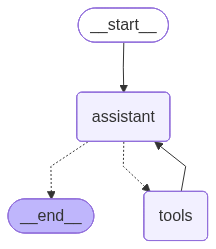

In [20]:
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.prebuilt import ToolNode, tools_condition
from langchain_core.tools import tool
from langchain_core.messages import SystemMessage, HumanMessage

# Graph 
builder = StateGraph(MessagesState)

# Define nodes: these do the work
builder.add_node("assistant", assistant)
builder.add_node("tools", ToolNode(tools))

# Define edges: these determine how the control flow moves
builder.add_edge(START, "assistant")
builder.add_conditional_edges(
    "assistant",
    tools_condition,
)
builder.add_edge("tools", "assistant")
react_graph = builder.compile()

#Show
display(Image(react_graph.get_graph(xray=True).draw_mermaid_png()))

In [25]:
from langgraph.checkpoint.memory import MemorySaver
memory = MemorySaver()
react_graph_memory = builder.compile(checkpointer=memory)

# Specify a thread
config = {"configurable": {"thread_id": "222"}}

# Specify an input 
messages = [HumanMessage(content="Are there any occurrences of a tornado in the Illes Baleares?")]

# Run
messages = react_graph_memory.invoke({"messages": messages}, config)
for m in messages ['messages']:
    m.pretty_print()

================================ Human Message =================================

Are there any occurrences of a tornado in the Illes Baleares?
================================== Ai Message ==================================
Tool Calls:
  semantic_search (fdd1e0d0-d7cc-462e-9939-4a69b9fdaca5)
 Call ID: fdd1e0d0-d7cc-462e-9939-4a69b9fdaca5
  Args:
    question: tornado Illes Baleares occurrences
================================= Tool Message =================================
Name: semantic_search



Result 1
Source: world_weather_attribution.pdf

). Referring to latest press reports, 24 people died and several hun-
dreds were injured. 
 
 
Fig. 1: Map of the US-state of Oklahoma with cities affected by the tornado  
outbreak of 20 May 2013. 
 
The Norman National Weather Service Forecast Office has issued a report about "The Tor-
nado Outbreak of May 20, 2013" on http://www.srh.noaa.gov/oun/?n=events-20130520
. 
 
 
Weather situation in Oklahoma on 20 May 2013

Result 2
Source: world_we

In [24]:
# Specify an input 
messages = [HumanMessage(content="Are there any occurrences of a tornado in the Illes Baleares?")]

# Run
messages = react_graph_memory.invoke({"messages": messages}, config)
for m in messages ['messages']:
    m.pretty_print()

================================ Human Message =================================

What sport event will be affected by climate change?
================================== Ai Message ==================================
Tool Calls:
  semantic_search (2322ef6d-0e5d-4129-ac6a-bb19a34ee32e)
 Call ID: 2322ef6d-0e5d-4129-ac6a-bb19a34ee32e
  Args:
    question: sport event affected by climate change
================================= Tool Message =================================
Name: semantic_search



Result 1
Source: https://www.worldweatherattribution.org/climate-change-big-player-at-fifa-world-cup-2026/

26°C Threshold 
Figure 5 shows the corresponding changes in the likelihood of 26°C WBGT events between the climate of 1994 and the 2026 climate, as well as between the 2026 climate and a future 0.7°C warmer climate. The results indicate clear increases in the likelihood of occurrences, attributable to human-induced climate change. A 26°C 1-day maximum WBGT represents conditions associated w

Now we add the number of tool calls and the names of the tools.

In [26]:
from langchain_core.messages import ToolMessage

# Specify an input 
messages = [HumanMessage(content="How many of them?")]

# Run
result = react_graph_memory.invoke({"messages": messages}, config)
for m in result ['messages']:
    m.pretty_print()

# Extract tool messages
tool_messages = [
    m for m in result["messages"]
    if isinstance(m, ToolMessage)
]

print("\nTools used:")
for i, tm in enumerate(tool_messages, 1):
    print(f"{i}. {tm.name}")

print(f"\nTotal tool calls: {len(tool_messages)}")

================================ Human Message =================================

Are there any occurrences of a tornado in the Illes Balears?
================================== Ai Message ==================================
Tool Calls:
  semantic_search (3c7a8736-c50b-4a56-ade8-04f7cca4cc28)
 Call ID: 3c7a8736-c50b-4a56-ade8-04f7cca4cc28
  Args:
    question: tornado Illes Balears occurrence
================================= Tool Message =================================
Name: semantic_search



Result 1
Source: world_weather_attribution.pdf

Fig. 4: Satellite image showing the storm system across Oklahoma on 20 May 2013  
at about 3 p.m. local time. [Source: NASA, Earth Observatory] 
 
 
The tornado of Newcastle / Moore on 20 May 2013 
 
On 20 May 2013, the region Newcastle – Moore – south Oklahoma City was extremely hard 
hit by the storms (Fig. 5; NOAA; National Weather Service Norman/OK
). A tornado ravaged 
the area over a length of approximately 27 km (17 miles). Referring to the